In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from traffic_monitoring_ml.utils import load_pickle, load_json, save_pickle
from traffic_monitoring_ml.config import COLLISION_VALUE_MAP_PATH, CASUALTY_VALUE_MAP_PATH, VEHICLE_VALUE_MAP_PATH, X_TRAIN_PATH, Y_TRAIN_PATH, GROUPS_TRAIN_PATH, SELECTED_FEATURES_PATH, X_TEST_PATH, Y_TEST_PATH, CATBOOST_MODEL_PATH, MODELS_DIR, MODEL_METRICS_DIR

from pathlib import Path
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, recall_score, precision_score, precision_recall_curve, roc_curve, auc

import optuna
from optuna.samplers import TPESampler

In [68]:
casualty_value_map = load_pickle(Path(CASUALTY_VALUE_MAP_PATH))
vehicle_value_map = load_pickle(Path(VEHICLE_VALUE_MAP_PATH))
collision_value_map = load_pickle(Path(COLLISION_VALUE_MAP_PATH))

## Carga de datos y features seleccionadas

Cargamos train y test, aplicamos los mapas de valores y filtramos únicamente las
features seleccionadas en el notebook anterior. Esto asegura que el modelo final
se entrena exactamente con las mismas variables que se evaluaron durante la selección.

In [69]:
X_train = (pd.read_parquet(Path(X_TRAIN_PATH))
           .replace(casualty_value_map)
           .replace(collision_value_map)
           .replace(vehicle_value_map))
X_test = (pd.read_parquet(Path(X_TEST_PATH))
           .replace(casualty_value_map)
           .replace(collision_value_map)
           .replace(vehicle_value_map))

y_train = pd.read_parquet(Path(Y_TRAIN_PATH)).squeeze()
y_test = pd.read_parquet(Path(Y_TEST_PATH)).squeeze()

groups_train = pd.read_parquet(Path(GROUPS_TRAIN_PATH)).squeeze()

In [70]:
selected_features = load_json(Path(SELECTED_FEATURES_PATH))
len(selected_features)

23

In [71]:
X_train = X_train[selected_features]
X_test = X_test[selected_features]

In [72]:
print(X_train.shape, X_test.shape)

(512334, 23) (128070, 23)


## Baseline cross validation

Antes de optimizar hiperparámetros, establecemos una línea base con `GroupKFold`
de 5 folds, respetando los grupos por `collision_index`. Usamos los hiperparámetros
por defecto del feature selection para tener un punto de referencia estable.

In [73]:
gkf = GroupKFold(n_splits=5)

cat_features = [col for col in X_train.columns if X_train[col].dtype in ['object', 'str']]

auc_results = []
for train_idx, val_idx in gkf.split(X_train, y_train, groups_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    eval_pool = Pool(X_val, y_val, cat_features=cat_features)

    model_cv = CatBoostClassifier(
        random_seed=42,
        iterations=1500,
        learning_rate=0.1,
        depth=8,
        verbose=100,
        eval_metric='AUC',
        task_type='GPU',
        devices='0',
        early_stopping_rounds=20,
        auto_class_weights='Balanced',
    )

    model_cv.fit(X_tr, y_tr, cat_features=cat_features, eval_set=eval_pool, use_best_model=True)

    auc = model_cv.get_best_score()['validation']['AUC']
    auc_results.append(auc)
    print(f"Fold AUC: {auc:.4f}")

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7295161	best: 0.7295161 (0)	total: 290ms	remaining: 7m 13s
100:	test: 0.7590827	best: 0.7590827 (100)	total: 12.3s	remaining: 2m 50s
200:	test: 0.7610639	best: 0.7610639 (200)	total: 24.5s	remaining: 2m 38s
300:	test: 0.7614445	best: 0.7614580 (291)	total: 37.3s	remaining: 2m 28s
400:	test: 0.7617052	best: 0.7617376 (391)	total: 49.4s	remaining: 2m 15s
bestTest = 0.7617376149
bestIteration = 391
Shrink model to first 392 iterations.
Fold AUC: 0.7617


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7247494	best: 0.7247494 (0)	total: 376ms	remaining: 9m 23s
100:	test: 0.7569486	best: 0.7569486 (100)	total: 12.3s	remaining: 2m 51s
200:	test: 0.7587911	best: 0.7587957 (196)	total: 24.9s	remaining: 2m 40s
bestTest = 0.759498626
bestIteration = 276
Shrink model to first 277 iterations.
Fold AUC: 0.7595


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7256514	best: 0.7256514 (0)	total: 179ms	remaining: 4m 27s
100:	test: 0.7564239	best: 0.7564239 (100)	total: 13s	remaining: 2m 59s
200:	test: 0.7587457	best: 0.7587457 (200)	total: 26.4s	remaining: 2m 50s
300:	test: 0.7597407	best: 0.7597637 (293)	total: 39.7s	remaining: 2m 38s
bestTest = 0.7598981559
bestIteration = 310
Shrink model to first 311 iterations.
Fold AUC: 0.7599


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7232020	best: 0.7232020 (0)	total: 341ms	remaining: 8m 31s
100:	test: 0.7575109	best: 0.7575109 (100)	total: 13s	remaining: 3m
200:	test: 0.7596864	best: 0.7596914 (199)	total: 25.9s	remaining: 2m 47s
300:	test: 0.7602769	best: 0.7603249 (288)	total: 39.2s	remaining: 2m 35s
bestTest = 0.7603248954
bestIteration = 288
Shrink model to first 289 iterations.
Fold AUC: 0.7603


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7251278	best: 0.7251278 (0)	total: 153ms	remaining: 3m 48s
100:	test: 0.7552201	best: 0.7552209 (99)	total: 14.6s	remaining: 3m 21s
200:	test: 0.7570072	best: 0.7570072 (200)	total: 29.6s	remaining: 3m 11s
bestTest = 0.757309854
bestIteration = 278
Shrink model to first 279 iterations.
Fold AUC: 0.7573


In [74]:
print(f'Baseline model CV AUC score mean: {np.array(auc_results).mean()}')
print(f'Baseline model CV STD: {np.array(auc_results).std()}')

Baseline model CV AUC score mean: 0.7597538292407989
Baseline model CV STD: 0.0014366973013358597


## Optimización de hiperparámetros con Optuna

Usamos Optuna con el sampler TPE (Tree-structured Parzen Estimator) para buscar
eficientemente la mejor combinación de hiperparámetros. Para acelerar el proceso,
trabajamos sobre una muestra representativa del 20% del train, manteniendo la
estructura de grupos. Los parámetros explorados son:

- `learning_rate`: controla el tamaño del paso en el boosting.
- `depth`: profundidad máxima de los árboles.
- `l2_leaf_reg`: regularización L2 para evitar overfit.
- `bagging_temperature`: aleatoriedad en el bagging de muestras.
- `random_strength`: aleatoriedad en la selección de splits.

Se ejecutan 20 trials y se seleccionan los parámetros que maximizan el AUC en validación.

In [83]:
gss_sample = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
sample_idx, _ = next(gss_sample.split(X_train, y_train, groups_train))

X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]
groups_sample = groups_train.iloc[sample_idx]

def objective(trial):
    params = {
        'random_seed': 42,
        'iterations': 1500,
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 1),
        'verbose': False,
        'eval_metric': 'AUC',
        'early_stopping_rounds': 20,
        'auto_class_weights': 'Balanced',
        'task_type': 'GPU',
        'devices': '0'
    }
    gkf_opt = GroupKFold(n_splits=2)
    auc_results = []
    for train_idx, val_idx in gkf_opt.split(X_sample, y_sample, groups_sample):
        X_tr, X_val = X_sample.iloc[train_idx], X_sample.iloc[val_idx]
        y_tr, y_val = y_sample.iloc[train_idx], y_sample.iloc[val_idx]

        eval_pool = Pool(X_val, y_val, cat_features=cat_features)

        model_opt = CatBoostClassifier(**params)
        model_opt.fit(X_tr, y_tr, cat_features=cat_features, eval_set=eval_pool, use_best_model=True)

        preds = model_opt.predict_proba(X_val)[:, 1]
        auc_results.append(roc_auc_score(y_val, preds))

    return np.array(auc_results).mean()

sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"Best AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-05-11 19:03:03,751] A new study created in memory with name: no-name-679c333a-14f6-4494-a96e-e715084990df


  0%|          | 0/20 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[I 2026-05-11 19:04:17,609] Trial 0 finished with value: 0.7512027092371418 and parameters: {'learning_rate': 0.09781801964118501, 'depth': 10, 'l2_leaf_reg': 7.587945476302646, 'bagging_temperature': 0.5986584841970366, 'random_strength': 0.15601864044243652}. Best is trial 0 with value: 0.7512027092371418.


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


...

[I 2026-05-11 19:23:50,882] Trial 17 finished with value: 0.7518482082639288 and parameters: {'learning_rate': 0.0819299902082084, 'depth': 9, 'l2_leaf_reg': 2.799042278571836, 'bagging_temperature': 0.021230673008582113, 'random_strength': 0.007703863125203325}. Best is trial 12 with value: 0.7536050480010559.


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[I 2026-05-11 19:24:32,638] Trial 18 finished with value: 0.7526502001110189 and parameters: {'learning_rate': 0.11630625240011899, 'depth': 7, 'l2_leaf_reg': 4.736859547269701, 'bagging_temperature': 0.22815267029068392, 'random_strength': 0.8204722531866918}. Best is trial 12 with value: 0.7536050480010559.


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[I 2026-05-11 19:25:20,230] Trial 19 finished with value: 0.7524350429366187 and parameters: {'learning_rate': 0.11793668462358965, 'depth': 9, 'l2_leaf_reg': 9.723428668438462, 'bagging_temperature': 0.12782432428264007, 'random_strength': 0.5640019711136135}. Best is trial 12 with value: 0.7536050480010559.
Best AUC: 0.7536
Best params: {'learning_rate': 0.05114503882083299, 'depth': 7, 'l2_leaf_reg': 3.6544467622105867, 'bagging_temperature': 0.2922384655019864, 'random_strength': 0.34251599373775665}


### Verificación de cross validation con los parámetros de Optuna

In [84]:
gkf_opt = GroupKFold(n_splits=5)
best_params = {
    'learning_rate': 0.05114503882083299,
    'depth': 7,
    'l2_leaf_reg': 3.6544467622105867,
    'bagging_temperature': 0.2922384655019864,
    'random_strength': 0.34251599373775665
}
cat_features = [col for col in X_train.columns if X_train[col].dtype in ['object', 'str']]
auc_results = []

for train_idx, val_idx in gkf_opt.split(X_train, y_train, groups_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    eval_pool = Pool(X_val, y_val, cat_features=cat_features)

    model_opt = CatBoostClassifier(
        **best_params,
        iterations=1500,
        random_seed=42,
        verbose=100,
        eval_metric='AUC',
        task_type='GPU',
        devices='0',
        early_stopping_rounds=20,
        auto_class_weights='Balanced',
    )
    model_opt.fit(X_tr, y_tr, cat_features=cat_features, eval_set=eval_pool, use_best_model=True)

    preds = model_opt.predict_proba(X_val)[:, 1]
    auc_results.append(roc_auc_score(y_val, preds))

print(f'Best hyperparam model CV AUC score mean: {np.array(auc_results).mean()}')
print(f'Best hyperparam model CV STD: {np.array(auc_results).std()}')

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7268497	best: 0.7268497 (0)	total: 341ms	remaining: 8m 31s
100:	test: 0.7553653	best: 0.7553653 (100)	total: 11s	remaining: 2m 32s
200:	test: 0.7593324	best: 0.7593324 (200)	total: 22s	remaining: 2m 21s
300:	test: 0.7608889	best: 0.7608889 (300)	total: 33.1s	remaining: 2m 11s
400:	test: 0.7617688	best: 0.7617688 (400)	total: 44.6s	remaining: 2m 2s
500:	test: 0.7622099	best: 0.7622099 (500)	total: 56.3s	remaining: 1m 52s
600:	test: 0.7624265	best: 0.7624294 (599)	total: 1m 8s	remaining: 1m 42s
700:	test: 0.7626026	best: 0.7626026 (700)	total: 1m 20s	remaining: 1m 32s
bestTest = 0.7626929283
bestIteration = 767
Shrink model to first 768 iterations.


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7233884	best: 0.7233884 (0)	total: 364ms	remaining: 9m 6s
100:	test: 0.7527780	best: 0.7527780 (100)	total: 11.9s	remaining: 2m 45s
200:	test: 0.7565803	best: 0.7565803 (200)	total: 24.4s	remaining: 2m 37s
300:	test: 0.7581045	best: 0.7581045 (300)	total: 37s	remaining: 2m 27s
400:	test: 0.7587300	best: 0.7587300 (400)	total: 49.2s	remaining: 2m 14s
500:	test: 0.7591244	best: 0.7591300 (498)	total: 1m 2s	remaining: 2m 4s
600:	test: 0.7594049	best: 0.7594093 (598)	total: 1m 15s	remaining: 1m 52s
700:	test: 0.7596628	best: 0.7596628 (700)	total: 1m 29s	remaining: 1m 41s
800:	test: 0.7597557	best: 0.7597768 (788)	total: 1m 43s	remaining: 1m 30s
bestTest = 0.7597768307
bestIteration = 788
Shrink model to first 789 iterations.


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7219189	best: 0.7219189 (0)	total: 400ms	remaining: 9m 59s
100:	test: 0.7516591	best: 0.7516591 (100)	total: 12s	remaining: 2m 46s
200:	test: 0.7559976	best: 0.7559976 (200)	total: 24.5s	remaining: 2m 38s
300:	test: 0.7578338	best: 0.7578338 (300)	total: 37.4s	remaining: 2m 29s
400:	test: 0.7586887	best: 0.7586887 (400)	total: 50.1s	remaining: 2m 17s
500:	test: 0.7593266	best: 0.7593270 (499)	total: 1m 2s	remaining: 2m 5s
600:	test: 0.7596523	best: 0.7596523 (600)	total: 1m 15s	remaining: 1m 52s
700:	test: 0.7598794	best: 0.7599081 (694)	total: 1m 27s	remaining: 1m 40s
bestTest = 0.7599081397
bestIteration = 694
Shrink model to first 695 iterations.


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7200237	best: 0.7200237 (0)	total: 333ms	remaining: 8m 18s
100:	test: 0.7529329	best: 0.7529329 (100)	total: 12s	remaining: 2m 46s
200:	test: 0.7571011	best: 0.7571011 (200)	total: 24.7s	remaining: 2m 39s
300:	test: 0.7586637	best: 0.7586637 (300)	total: 37.4s	remaining: 2m 29s
400:	test: 0.7595994	best: 0.7595994 (400)	total: 50.2s	remaining: 2m 17s
500:	test: 0.7600571	best: 0.7600571 (500)	total: 1m 2s	remaining: 2m 5s
600:	test: 0.7603678	best: 0.7603678 (600)	total: 1m 15s	remaining: 1m 52s
700:	test: 0.7606679	best: 0.7606725 (697)	total: 1m 28s	remaining: 1m 40s
bestTest = 0.7607313693
bestIteration = 739
Shrink model to first 740 iterations.


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7215653	best: 0.7215653 (0)	total: 135ms	remaining: 3m 22s
100:	test: 0.7513506	best: 0.7513506 (100)	total: 12.7s	remaining: 2m 55s
200:	test: 0.7551726	best: 0.7551726 (200)	total: 25.2s	remaining: 2m 42s
300:	test: 0.7566350	best: 0.7566350 (300)	total: 37.9s	remaining: 2m 30s
400:	test: 0.7575687	best: 0.7575702 (399)	total: 51.4s	remaining: 2m 20s
500:	test: 0.7580816	best: 0.7580816 (500)	total: 1m 4s	remaining: 2m 9s
600:	test: 0.7583991	best: 0.7583991 (600)	total: 1m 17s	remaining: 1m 56s
bestTest = 0.7584877312
bestIteration = 642
Shrink model to first 643 iterations.
Best hyperparam model CV AUC score mean: 0.7603194092237635
Best hyperparam model CV STD: 0.0013872017301069157


### Entrenar modelo final

In [112]:
gss_final = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss_final.split(X_train, y_train, groups_train))

X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
eval_pool = Pool(X_val, y_val, cat_features=cat_features)

cat_features = [col for col in X_train.columns if X_train[col].dtype in ['object', 'str']]

best_params = {
    'learning_rate': 0.05114503882083299,
    'depth': 7,
    'l2_leaf_reg': 3.6544467622105867,
    'bagging_temperature': 0.2922384655019864,
    'random_strength': 0.34251599373775665
}

model_final = CatBoostClassifier(
    **best_params,
    iterations=1500,
    random_seed=42,
    verbose=100,
    eval_metric='AUC',
    task_type='GPU',
    devices='0',
    early_stopping_rounds=10,
    auto_class_weights='Balanced',
)
model_final.fit(X_tr, y_tr, cat_features=cat_features, eval_set=eval_pool, use_best_model=True)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7251324	best: 0.7251324 (0)	total: 350ms	remaining: 8m 45s
100:	test: 0.7548120	best: 0.7548120 (100)	total: 10.9s	remaining: 2m 31s
200:	test: 0.7585840	best: 0.7585840 (200)	total: 21.6s	remaining: 2m 19s
300:	test: 0.7599833	best: 0.7599833 (300)	total: 32s	remaining: 2m 7s
bestTest = 0.7606374621
bestIteration = 370
Shrink model to first 371 iterations.


CatBoostClassifier(auto_class_weights='Balanced', bagging_temperature=0.2922384655019864, depth=7, devices='0', early_stopping_rounds=10, eval_metric='AUC', iterations=1500, l2_leaf_reg=3.6544467622105867, learning_rate=0.05114503882083299, random_seed=42, random_strength=0.34251599373775665, task_type='GPU', verbose=100)

In [113]:
pred_train_p = model_final.predict_proba(X_train)[:, 1]
pred_test_p = model_final.predict_proba(X_test)[:, 1]

pred_train = model_final.predict(X_train)
pred_test = model_final.predict(X_test)

### Evaluación del modelo

El modelo final tiene un AUC de 0.755 en test frente a 0.776 en train. La diferencia de 0.021 indica una generalización correcta sin mucho overfitting. Este resultado se ha obtenido respetando la estructura de grupos mediante GroupShuffleSplit, evitando que víctimas del mismo accidente aparecieran simultáneamente en train y test, lo que habría inflado las métricas.

Con el umbral por defecto el modelo detecta el 71.74% de los accidentes severos, con una precisión del 34.3%. De cada 3 alarmas de severidad alta, aproximadamente 2 son falsas alarmas. De 25.775 accidentes severos en test, el modelo falla en detectar 7.540.

In [115]:
print(f'AUC train: {roc_auc_score(y_train, pred_train_p)}')
print(f'AUC test: {roc_auc_score(y_test, pred_test_p)}')
print(f'AUC diff: {roc_auc_score(y_train, pred_train_p) - roc_auc_score(y_test, pred_test_p)}')
print()
print(f'TRAIN recall: {recall_score(y_train, pred_train)}')
print(f'TEST recall: {recall_score(y_test, pred_test)}')
print()
print(f'TRAIN precision: {precision_score(y_train, pred_train)}')
print(f'TEST precision: {precision_score(y_test, pred_test)}')
print()
print(classification_report(y_test, pred_test ))
print(confusion_matrix(y_test, pred_test))

AUC train: 0.776889530546616
AUC test: 0.7557853493175464
AUC diff: 0.021104181229069652

TRAIN recall: 0.7463143657617621
TEST recall: 0.7174393792434529

TRAIN precision: 0.3569164664572168
TEST precision: 0.342368362586092

              precision    recall  f1-score   support

           0       0.90      0.65      0.76    102295
           1       0.34      0.72      0.46     25775

    accuracy                           0.67    128070
   macro avg       0.62      0.69      0.61    128070
weighted avg       0.79      0.67      0.70    128070

[[66775 35520]
 [ 7283 18492]]


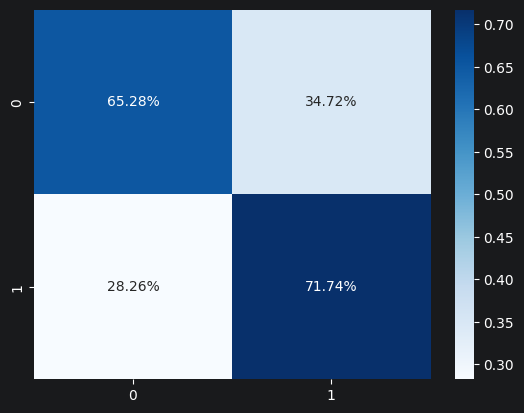

In [123]:
sns.heatmap(confusion_matrix(y_test, pred_test, normalize='true'), annot=True, cmap='Blues', fmt='.2%');

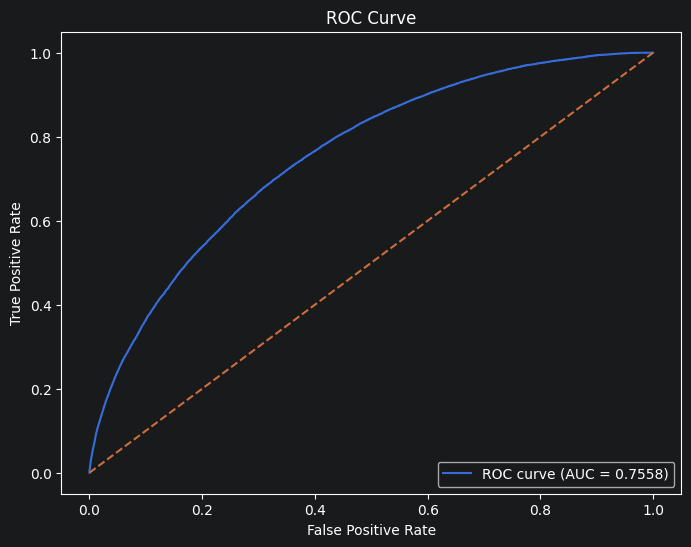

In [125]:
fpr, tpr, thresholds = roc_curve(y_test, pred_test_p)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.show()

### Ajuste del umbral

El no detectar un accidente severo es mucho mas grave que el de enviar una ambulancia innecesariamente. Por este motivo se ajusta el umbral de clasificación a 0.268, con el objetivo de alcanzar un recall del 95% en la clase severa.
Esto significa que se enviarán recursos de más cuando no es necesario, pero se reduce considerablemente el riesgo de dejar sin atención inmediata a una víctima grave.

In [104]:
y_probs = model_final.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
target_recall = 0.95

idx = np.where(recalls >= target_recall)[0][-1]

best_threshold = thresholds[idx]
best_precision = precisions[idx]
best_recall = recalls[idx]

print(f'Threshold: {best_threshold}')
print(f'Recall: {best_recall}')
print(f'Precision: {best_precision}')

Threshold: 0.26781623506651914
Recall: 0.9500290979631426
Precision: 0.2641303878845407


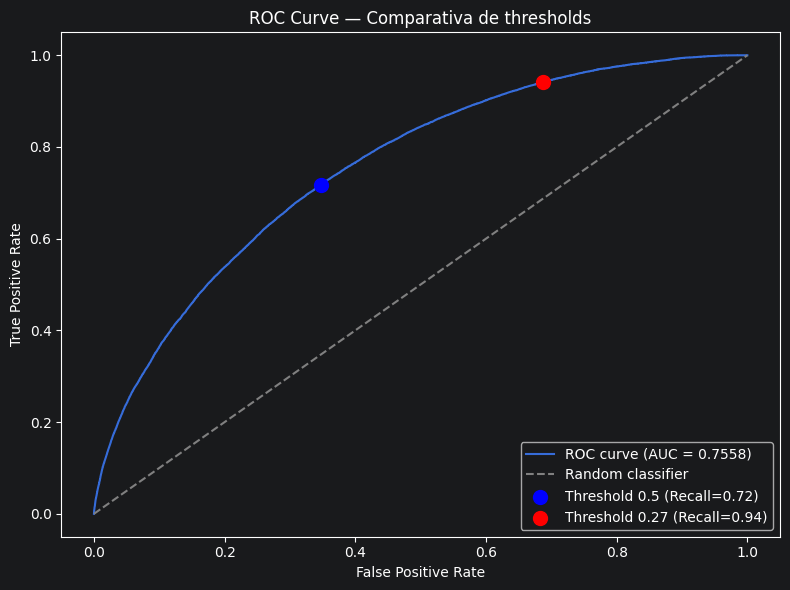

In [117]:
fpr, tpr, thresholds = roc_curve(y_test, pred_test_p)
roc_auc = auc(fpr, tpr)

# Encontrar el índice del threshold óptimo
optimal_idx = np.argmin(np.abs(thresholds - best_threshold))
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')

# Punto del threshold por defecto (0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(fpr[default_idx], tpr[default_idx],
            color='blue', zorder=5, s=100,
            label=f'Threshold 0.5 (Recall={tpr[default_idx]:.2f})')

# Punto del threshold optimizado para recall
plt.scatter(optimal_fpr, optimal_tpr,
            color='red', zorder=5, s=100,
            label=f'Threshold {best_threshold:.2f} (Recall={optimal_tpr:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Comparativa de thresholds')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [116]:
evaluation_scores = {
    'auc': 0.7557853493175464,
    'default_threshold': {
        'precision': 0.3435578249040289,
        'recall': 0.715266731328807,
        'threshold': 0.5
    },
    'recall_threshold': {
        'precision': 0.2641303878845407,
        'recall': 0.9500290979631426,
        'threshold': 0.26781623506651914
    },
}

## Guardar del modelo y las métricas de evaluación

Guardamos el modelo con el formato nativo de CatBoost, que preserva
toda la información necesaria para hacer inferencia sin necesidad de reentrenar.

In [ ]:
model_final.save_model(str(Path(CATBOOST_MODEL_PATH)))

save_pickle(Path(MODELS_DIR / 'best_params.pkl'), best_params)
save_pickle(Path(MODEL_METRICS_DIR / 'evaluation_scores.pkl'), evaluation_scores)